<a href="https://colab.research.google.com/github/carthomp99/ML-SARShipDetection-Tutorial/blob/main/ML-SARShipDetection-Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAR Ship Detection - YOLO and RT-DETR Comparison Tutorial
##### __by Carter Thompson__
##### updated: 13 May 2026

### The goal of this tutorial is to show how to train, utilize, and compare the efficacy of two machine learning models for SAR Ship Detection.

YOLO models have become mainstays in the digital image processing boom through the mid-2010s to the present; they are quick and easy to implement, but have sometimes lacked in accuracy (though newer models continue to improve on this). DETR transformer models are very robust, but have lacked the speeds YOLO models could achieve - until now, with the development of RT-DETR models that test at real-time speeds.

This tutorial will show you how to prepare, train, optimize, and test both of these models separately, and provide you tools to compare their performance metrics against one another if that interests you.



### Contents:
Section 0 details important setup steps, including library installations and file downloads. If you have a dataset saved to Google Drive, see section 0.2 for more information on how to utilize that in this tutorial, or in Colab notebooks generally.

Section 1 explores dataset setup, providing resources on where to find helpful SAR image datasets and how to structure your directories for use down the line. Section 1.2 details how to split a dataset for fivefold CV, though I decided against demonstrating the cross validation process in this tutorial, as it is too resource intensive for free users.

Section 2 is a more conceptual section, exploring the two models in use in greater detail. This includes information on the structure of the input, intermediate, and output layers produced by the models. I have included figures found in the original papers describing these two models, see references for more information. This section is very code-light, and may not be useful to a more seasoned ML user.

Section 3 explores optimization parameters that will be put to use in sections 4 and 5. This is another code-light section intended mostly for deepening understanding of ML concepts. In other words, I wrote this section out more for me than for the user, so that I could more fully understand the principles of machine learning at play here.

Section 4 shows how to train both models on SAR data. For each model there will be two parts: a design step, which relies on fivefold cross validation to investigate model performance, and a production step, which trains on the full dataset in order to produce a production model.

Section 5 utilizes the insights gained from section 3 as well as those learned from training the model. Fine-tuning the model is discussed in greater detail. A brief example of an optimization loop is provided with instruction on how to expand the scope to your needs.

Section 6 finally puts the models we have spent all this time developing to the test on novel data. I will demonstrate this on a single image, but the principles can be scaled for testing of entire directories with very simple changes that I will detail.

Finally, in section 7, I will compare the results of the tests with the two models, and provide useful code to A) investigate performance of individual models and B) compare the models one against the other.

# References

[1] T. Zhang, X. Zhang, J. Li, X. Xu, B. Wang, X. Zhan, Y. Xu, X. Ke, T. Zeng, H. Su et al., “SAR ship detection dataset (SSDD): Official release and comprehensive data analysis,” Remote Sensing, vol. 13, no. 18, p. 3690, 2021, doi: 10.3390/rs13183690.

[2] G. Jocher and J. Qiu, Ultralytics YOLO26. 2026. [Online]. Available: https://github.com/ultralytics/ultralytics

[3] R. Sapkota and M. Karkee, “Ultralytics YOLO Evolution: An Overview of YOLO26, YOLO11, YOLOv8 and YOLOv5 Object Detectors for Computer Vision and Pattern Recognition,” arXiv:2510.09653, 2025. doi: 10.48550/arXiv.2510.09653.

[4] Ultralytics, “Baidu’s RT-DETR: A Vision Transformer-Based Real-Time Object Detector,” Ultralytics Docs. [Online]. Available: . [Accessed: May 13, 2026].

[5] W. Lv et al., “DETRs Beat YOLOs on Real-time Object Detection,” arXiv:2304.08069v3, 2024. doi: 10.48550/arXiv.2304.08069

# \#0. General Setup and Overview

## 0.1 - Top Level Library Requirements

In [1]:
import time
import datetime
import os
import json
from collections import defaultdict
import shutil
from google.colab import files
from google.colab import drive

# Data Manipulation
import numpy as np
import pandas as pd

# Plotting/Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ML Libraries
import torch
from sklearn.model_selection import KFold

# Suppress per-epoch text output - remove comments to do this!
# I recommend you let it run with output once, but once you get the
# idea you could quiet it for future runs
'''
os.environ["YOLO_VERBOSE"] = "False"
os.environ["TQDM_DISABLE"] = "1"
'''

# Ultralytics install and imports
try:
  from ultralytics import YOLO
except ImportError:
  %pip install -q ultralytics
  from ultralytics import YOLO
  from ultralytics import RTDETR
else:
  from ultralytics import RTDETR

# Dataset and Model Gets from GitHub
if not os.path.exists("SSDD.zip"):
  !wget -q https://github.com/carthomp99/ML-SARShipDetection-Tutorial/raw/main/SSDD.zip
  !unzip -q ./SSDD.zip
if not os.path.exists("CT_yolo26_SAR.pt"):
  !wget -q https://github.com/carthomp99/ML-SARShipDetection-Tutorial/raw/main/CT_yolo26_SAR.pt
if not os.path.exists("CT_rtdetr_SAR.pt"):
  !wget -q https://github.com/carthomp99/ML-SARShipDetection-Tutorial/raw/main/CT_rtdetr_SAR.pt
if not os.path.exists("yolo_prod_results.zip"):
  !wget -q https://github.com/carthomp99/ML-SARShipDetection-Tutorial/raw/main/yolo_prod_results.zip
  !unzip -q ./yolo_prod_results.zip -d ./yolo_prod_results
if not os.path.exists("detr_prod_results.zip"):
  !wget -q https://github.com/carthomp99/ML-SARShipDetection-Tutorial/raw/main/detr_prod_results.zip
  !unzip -q ./detr_prod_results.zip -d ./detr_prod_results

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 0.2 - Google Drive Mount
You can mount your Google Drive to this Colab runtime using the code below. If you wish to access data from Drive for training, optimizing, testing, or even just the data analysis steps available in section 7, do the following:

1: Run this code snippet to mount Google Drive

In [ ]:
drive.mount('/content/drive')

2: Authorize access via the pop-up window that appears. Select the appropriate Google account and click 'Allow.'

3: Your files will appear in ./content/drive/MyDrive/. You can navigate them using standard Linux/Unix terminal commands, or utilize the Files UI on the left.


For convenience, you may wish to use a variable to store the Drive filepath, so that you can append specific paths to that variable later. For example, if I had a dataset stored on Google Drive in a folder called 'Colab,' I could access it like so:

In [ ]:
drive_path = '/content/drive'
drive_dataset_path = f'{drive_path}/Colab/dataset.zip'

Running this snippet will store these variables for as long as the runtime persists. Feel free to use or modify them for your purposes.

## 0.3 - Dataset Requirements
For the purposes of this tutorial I train, validate, and test my models on subsets of the SAR Ship Detection Dataset [1]. A prepared version of this dataset specifically for this tutorial can be found on my GitHub, and was automatically loaded in step 0.1.

This dataset is composed of 1,160 SAR images, taken both at shore and offshore on open waters. The training set contains 928 images, and the testing set contains 232 images (80-20 split). The size on disk of the full dataset, including annotation information, is approximately 64.2 MB.

To access this dataset for use in this project or others, use !wget in a Colab codeblock to download the file from an internet URL. In addition to the .zip file available in my GitHub repository, downloads of the SSDD are also available at this [Google Drive link](https://drive.google.com/file/d/1glNJUGotrbEyk43twwB9556AdngJsynZ/view?usp=sharing); all 1160 raw images with no annotations can be found [on Kaggle](https://www.kaggle.com/datasets/mrearthworm/ssdd-sar-images).

To use your own dataset, you can use !wget to download your .zip file from your own source URL. See the below code block for an example of proper syntax, as well as the unzip command.

`!wget -q https://url/raw/filepath/filename.extension`

Simply replace the url with the url you want to download from. Note that you need to use `/raw` to download raw files, otherwise you will download the HTML of the site itself and not the file you seek. For an example of `!wget` see section 0.1.

Note: The -q tag in this and other commands suppresses verbose output as a matter of personal preference. Feel free to remove this tag, especially for debugging contexts.

To unzip, use the following code:
`!unzip -q ./file-to-unzip.zip`

If you wish to unzip into a subdirectory, append this:
`-d ./desired-output-directory`

### 0.3.1 - Personal Datasets
If you choose to use your own data, you will need to change variables in certain sections to accommodate. Bolded sections are required, while non-bolded sections *may* be of use if restructured, such as the COCO to YOLO annotation conversions in section 1.

* Section 1.1 (COCO conversion)
* Section 1.2 (Kfold split and/or .yaml generation)
* __Section 4.1 (Provide your own .yaml file for training)__
* __Section 4.2 (See above)__
* __Section 5.1 (Provide your own .yaml file for optimization)__
* __Section 5.2 (See above)__
* Section 6.1 (If you want to test on images from your own data)
* Section 6.2 (See above)

## 0.4 - Hardware
YOLO models are optimized to run well on both CPU and GPU hardware. If you are only interested in the __YOLO testing__ portions of this tutorial, feel free to use the CPU runtime listed in Colab. For the sake of the training and optimization steps, as well as any RT-DETR portions and the comparisons between both models, this tutorial assumes usage of the free T4 GPU runtimes available through Colab. Ensure you have selected this option under `Runtime > Change runtime type` before attempting to run any of the code blocks listed below.

Note: If you ran the library steps before switching runtimes, ensure you run them again in the T4 GPU runtime or you will encounter errors later on.

## 0.5 - Approximate Execution Times

Approximate execution times were estimated based on the duration of each code block running in the Colab T4 GPU runtime. Results may vary. Note that CPU runtimes are absolutely impractical for training purposes, though they may be suitable for testing.

Additionally, GPU runtimes under free Colab settings may be interrupted - don't be like me and get stopped hours into a training run, be cautious and regard the usage warnings.
- Library setup/installs: ~30s initial, < 1s for repeat runs
- Dataset setup: ~1s
- YOLO Production Model: ~40min
- DETR Production Model: ~1.5-2.5 hr
  - (I experienced large fluctuations due to early quitting sometimes happening very soon and sometimes not)
- Fine-Tune YOLO (10 epochs): ~5min
- Fine-Tune DETR (10 epochs): ~15min
- Test YOLO: < 1s
- Test DETR: < 1s
- Comparison and Analysis: ~5s

# \#1. Dataset Tutorial

## 1.1 - Annotation Structure
The SSDD comes with COCO-style .json annotations. Ultralytics expects the following structure for its models: a single .txt file per image with each line in the file taking the form

`<class_id> <x_center> <y_center> <width> <height>`

There is only a single class_id for this tutorial as we are __only__ concerned with identifying ships among any and all other image data.

The following code converts COCO to the required form. For this tutorial I will run it on both the test and train sets of the SSDD. To run on your own data, simply modify the directory paths in the second block below.

In [ ]:
def convert_coco(json_path, images_dir, labels_dir):
  os.makedirs(labels_dir, exist_ok=True)

  # load json
  with open(json_path, "r") as f:
      data = json.load(f)

  # map image ids to info
  images = {img["id"]: img for img in data["images"]}

  # match annotations to images
  annots_by_image = defaultdict(list)
  for ann in data["annotations"]:
      annots_by_image[ann["image_id"]].append(ann)

  # convert format
  missing_images = 0
  written_files = 0

  for image_id, img_info in images.items():
      file_name = img_info["file_name"]
      w, h = img_info["width"], img_info["height"]

      # IMPORTANT: adjust path if needed
      img_path = os.path.join(images_dir, file_name)

      if not os.path.exists(img_path):
          missing_images += 1
          continue

      label_path = os.path.join(
          labels_dir,
          file_name.replace(".jpg", ".txt")
      )

      lines = []

      for ann in annots_by_image.get(image_id, []):
          x, y, bw, bh = ann["bbox"]

          # COCO → YOLO normalization
          x_center = (x + bw / 2) / w
          y_center = (y + bh / 2) / h
          bw_norm = bw / w
          bh_norm = bh / h

          cls = ann["category_id"]

          lines.append(f"{cls} {x_center:.6f} {y_center:.6f} {bw_norm:.6f} {bh_norm:.6f}")

      # write only if annotations exist
      if lines:
          with open(label_path, "w") as f:
              f.write("\n".join(lines))
          written_files += 1

  # summarize and done
  print("Done.")
  print(f"Labels written: {written_files}")
  print(f"Missing images skipped: {missing_images}")

In [ ]:
# Test set conversion
json_path = "./SSDD/annotations/test.json"
images_dir = "./SSDD/images/test"
labels_dir = "./SSDD/labels/test"

convert_coco(json_path, images_dir, labels_dir)

# Train set conversion
json_path = "./SSDD/annotations/train.json"
images_dir = "./SSDD/images/train"
labels_dir = "./SSDD/labels/train"

convert_coco(json_path, images_dir, labels_dir)

Done.
Labels written: 232
Missing images skipped: 0
Done.
Labels written: 928
Missing images skipped: 0


## 1.2 - Dataset Assembly

With labels generated appropriately, we now need to prepare .yaml files for our testing and training sets. These files direct the Ultralytics methods to the right location and help delineate the directory structure for the model. The following code creates .yaml files necessary for the creation of a population model using 100% of the dataset, rather than cross validating on a subset of data (which we will see later on in this section).

In [ ]:
yaml_content = """
path: SSDD/images
train: ./train
val: ./test

names:
  0: ship
""".strip()

with open('SSDD/images/train.yaml', "w") as f:
            f.write(yaml_content)

For certain ML projects, you may wish to restructure the training set to perform K-fold cross validation. To do this simply, we can utilize symlinks (symbolic links) which will act as shortcuts to our SSDD dataset files without directly copying each image K times.

The following code splits the training set, both images and labels, of the SSDD directory into five folds for training. It first creates an array of all file paths, then shuffles that array and divides it into five equal pieces. The `dataset` directory contains sub-directories for each of the five folds; each individual fold uses the contents of four of the five folds as training data and the fifth for validation. During the training process, we will test and validate across all five folds, and take the average performance.

You can use this fold-splitter for your own dataset by simply changing the image_dir and label_dir filepaths to your directory. To change K from 5 to whatever value you like, modify the code in line 8 to set n_splits to your desired K value.

__NOTE: Deleting files will cause issues with the symlinks as they require the original file to reference back to. Please avoid deleting files or directories, and note that resetting the runtime will similarly dispose of the symbolic directory until the splitter is run again.__

If you wish to __permanently__ modify your dataset to this format, simply change the symlink code and instead copy.

In [ ]:
image_dir = "SSDD/images/train"
label_dir = "SSDD/labels/train"

# Make an array of every image in the directory
images = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

# SKLearn helps us implement 5Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(images)):
    fold_dir = f"dataset/fold_{fold}"

    for split, indices in [("train", train_idx), ("val", val_idx)]:
        os.makedirs(f"{fold_dir}/images/{split}", exist_ok=True)
        os.makedirs(f"{fold_dir}/labels/{split}", exist_ok=True)

        for i in indices:
            img = images[i]
            lbl = img.replace(".jpg", ".txt")

            # Define target paths for symlinks
            target_image_path = f"{fold_dir}/images/{split}/{img}"
            target_label_path = f"{fold_dir}/labels/{split}/{lbl}"

            # Remove existing symlinks if they exist to prevent FileExistsError
            if os.path.exists(target_image_path):
                os.unlink(target_image_path)
            if os.path.exists(target_label_path):
                os.unlink(target_label_path)

            # symlink (fast & space-efficient) or copy
            os.symlink(
                os.path.abspath(f"{image_dir}/{img}"),
                target_image_path
            )
            os.symlink(
                os.path.abspath(f"{label_dir}/{lbl}"),
                target_label_path
            )
        # YAML generator per-fold
        yaml_content = f"""
path: {fold_dir}
train: images/train
val: images/val

names:
  0: ship
""".strip()

        yaml_path = os.path.join(fold_dir, f"data_fold_{fold}.yaml")

        with open(yaml_path, "w") as f:
            f.write(yaml_content)

print(f"Split complete at {datetime.datetime.now().strftime("%c")}.")

I personally decided against demonstrating K-fold validation in this tutorial as it very quickly ate away at my available GPU resources in Colab. However, the setup is relatively simple: modify the code in sections 4.1 and 4.2 to repeat the training K times, each time using f-strings to train on the data found in each symbolic fold directory.

Alternatively, you could separately perform training runs without an iterator by subsequently running the code in section 4. This may cut down on issues with the runtime, allowing you to separate fold training into parts. This comes at the cost of having to store the output data in K different places, so be sure you understand and have a plan of action to make use of the CV output in whatever format you have to collect it.

Note as well that files generated in Colab runtimes do NOT persist after runtime closes, and should be downloaded to your device's local storage if you intend to keep them.

# \#2. Model Description
This section explores the two models at work. You will see code examples of how to load and save models, as well as descriptions of the inner workings of each model. If you are already familiar with these models you may wish to skip forward to the training, testing, and tuning steps in sections 4, 5, and 6 respectively.

## 2.1 - YOLO Model
For the purposes of this tutorial, we will train using pretrained YOLO26 models provided within the Ultralytics library. See references [2] and [3] for more information on this latest YOLO iteration.

### 2.1.1 - Loading
To load a pretrained YOLO model, ensure first that the YOLO class is properly imported from ultralytics libraries, then use the following code:

In [ ]:
from ultralytics import YOLO

# Load an existing YOLO model in for use, then display its information
model = YOLO("yolo26n.pt")
model.info()

YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs


(260, 2572280, 0, 6.1192448)

You can replace `"yolo26n.pt"` with any PyTorch (.pt extension) YOLO model, including my trained `CT_yolo26_SAR.pt` model provided in this tutorial. Feel free to use this to load in your own models for testing or other tuning.

You can train any model using the model.train() method, controlling various hyperparameters. See sections 3.2 and 4.1 for more information on training.

You can test any model using the model() method on an image or directory of images. See section 6.1 for more information on testing.

### 2.1.2 - Saving
You can export any Ultralytics model using the .export() method.. The default export format is a PyTorch file, but export() can also generate ONNX, TensorRT, and other common model formats. Further information on model exporting can be found in the Ultralytics documentation here [<--- PUT THE LINK].

In [ ]:
# Export trained model to default PyTorch format
model.export()

Additionally, after training, you can use the following code to archive all run data:

```
# Save the entire run as a .zip archive
shutil.make_archive(
    "output_file_name",
    "zip",
    "target_directory_path"
)
files.download("output_file_name.zip")
```

This zips the entire run into one file, containing all plots, weights, and results data generated during training. Once training has completed, the `best.pt` file in the `weights` directory can be saved and used elsewhere as the best version of the model (accounting for potential early quitting effects). The `last.pt` file functions similarly, containing the model as it existed during the last executed epoch, which may be useful in certain contexts.

### 2.1.3 - Input Layer
YOLO input is an image tensor. YOLO models resize images to a fixed resolution for the sake of CNN efficiency. In cases where the resolutions do not already match ahead of time, the original aspect ratio can be preserved using padding. Images are also normalized for stability.

Every input is broken up into a grid, with each grid cell accounting for objects within itself. This will be explored in greater detail when discussing intermediate and outer layers.



### 2.1.4 - Output Layer
YOLO divides the image into an NxN grid. At each grid cell, the model predicts some number A anchors (this means that it suspects, at some level, that A objects exist in this cell).

Each anchor outputs a vector containing the predicted center coordinates of the predicted object, the width and height of the bounding box around the object, the "objectness" (likelihood that the thing being detected is actually an object), and the class it predicts this object is. Modern YOLO models use sigmoid activation functions for both objectness and class probabilities.

YOLO learns by minimizing bounding box loss, objectness loss, and classification loss. Bounding box losses are measured with intersection over union (IoU) functions, which measure overlap with the ground truth. Less overlap means high loss. Objectness losses are measured using binary cross-entropy (BCE) functions. Because "objectness" is a boolean measurement - true if there is an object, false if not - BCE can identify and severely punish differences in the predicted objectness and ground truth objectness. Classification losses typically use BCE functions as well.

### 2.1.5 - Intermediate Layers
YOLO is composed of three major parts. The CNN backbone of YOLO models extracts and maps features at different scales/resolutions for further analysis. Deeper layers have smaller resolutions, meaning they have very low detail but high semantics; shallow layers use higher resolutions but lack the context to describe objects within them.

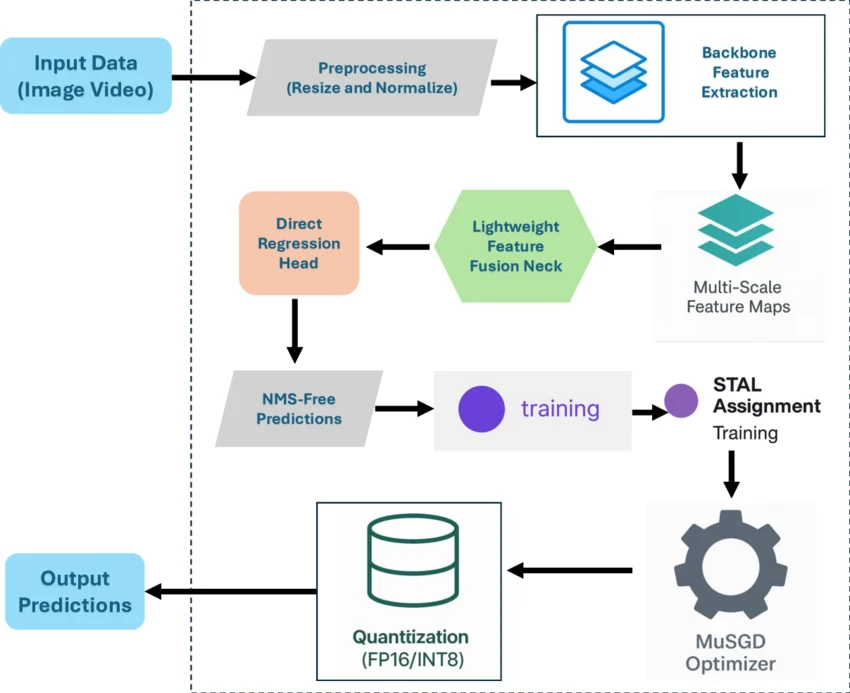

<figcaption>
    Figure 1. YOLO26 architecture as shown in the research paper [3].
  </figcaption>

The "neck" of the YOLO model combines these feature maps to maximize information. It utilizes a feature pyramid network (FPN) to send the semantic meaning from deep layers to shallow layers. Essentially, it uses a small resolution map (e.g. 20x20), upsamples it, and applies it to the medium resolution map (e.g. 40x40). Then it repeats this by upsampling that output and applying it to the large resolution (e.g. 80x80) map. This helps improve small-object detection.

The reverse of this is also done using a path aggregation network (PAN). This takes the FPN outputs and downsamples them back to their low resolutions, improving localization data for large objects that the FPN may have missed. These two processes create a feedback loop that helps identify objects and classifications at any scale.

Finally, now that we have rich feature maps at every scale, we need to convert them into actual bounding boxes and class predictions. The "head" of this model actually varies depending on the resolution of the map it receives. Detection heads include a small stack of convolutional layers that end with a prediction layer. This is what generates the actual anchors per each grid cell.

## 2.2 - RT-DETR Model

Ultralytics provides pretrained RT-DETR models within their Python API. These models can then be trained and subsequently saved for further use. The Ultralytics documentation [4] and the original RT-DETR development paper [5] should serve as additional helpful resources in understanding this model's capabilities.

### 2.2.1 - Loading
To load a pretrained RT-DETR model, ensure first that the RTDETR class is properly imported from ultralytics libraries, then use the following code:

In [ ]:
from ultralytics import RTDETR

# Load an existing RT-DETR model in for use, then display its information
model = RTDETR("rtdetr-l.pt")
model.info()

You can replace `"rtdetr-l.pt"` with any PyTorch (.pt extension) RT-DETR model, including CT_rtdetr_SAR.pt provided in this tutorial. Feel free to use this to load in your own models for testing or other tuning.

You can train any model using the model.train() method, controlling various hyperparameters. See sections 3.3 and 4.2 for more information on training.

You can test any model using the model() method on an image or directory of images. See section 6.2 for more information on testing.

### 2.2.2 - Saving
You can export any Ultralytics model using the .export() method.. The default export format is a PyTorch file, but export() can also generate ONNX, TensorRT, and other common model formats. Further information on model exporting can be found in the Ultralytics documentation here [<--- PUT THE LINK].

In [ ]:
# Export trained model to the default PyTorch format
model.export()

### 2.2.3 - Input Layer
RT-DTER input is an image tensor. Images are resized and normalized. Unlike the YOLO model, no anchor boxes are defined at the input stage.

### 2.2.4 - Output Layer
The model outputs a fixed number of object queries predicting bounding boxes and class probabilities. This is another difference from the YOLO model, which predicts per grid cell of the image. Each query produces a bounding box and class probabilities within that bounding box. This includes a "no object class" whose probability is high when nothing is detected. Query bounding boxes use sigmoid activation functions, while the class probabilities use softmax.

Like other DETR models, RT-DETR uses bipartite matching which uses a cost function to find the best one-to-one match between the predicted boxes and the ground truth. Both classification costs and bounding box costs are measured based on the probabilities calculated by the activation functions. The bounding box cost specifically is composed of both an L1 distance component and an intersection over union (IoU) component.

Many more queries than objects are generated per image, but the unmatched predictions are not useless - they are treated as "no object" objects with only classification losses applied. Thus, the model learns from its empty space as well as its matches. This feature of DETR models eliminates duplicate detections of objects, therefore removing the overhead costs of non-max suppression entirely.

### 2.2.5 - Intermediate Layers
RT-DETR is a hybrid model that uses both a CNN and a transformer. The backbone is a CNN feature extractor that converts the raw image into a feature map. Early layers of the map may only focus on edges of objects or textures. By the middle stages, specific shapes start to appear, and deeper and deeper layers have more complex and complete objects mapped out.



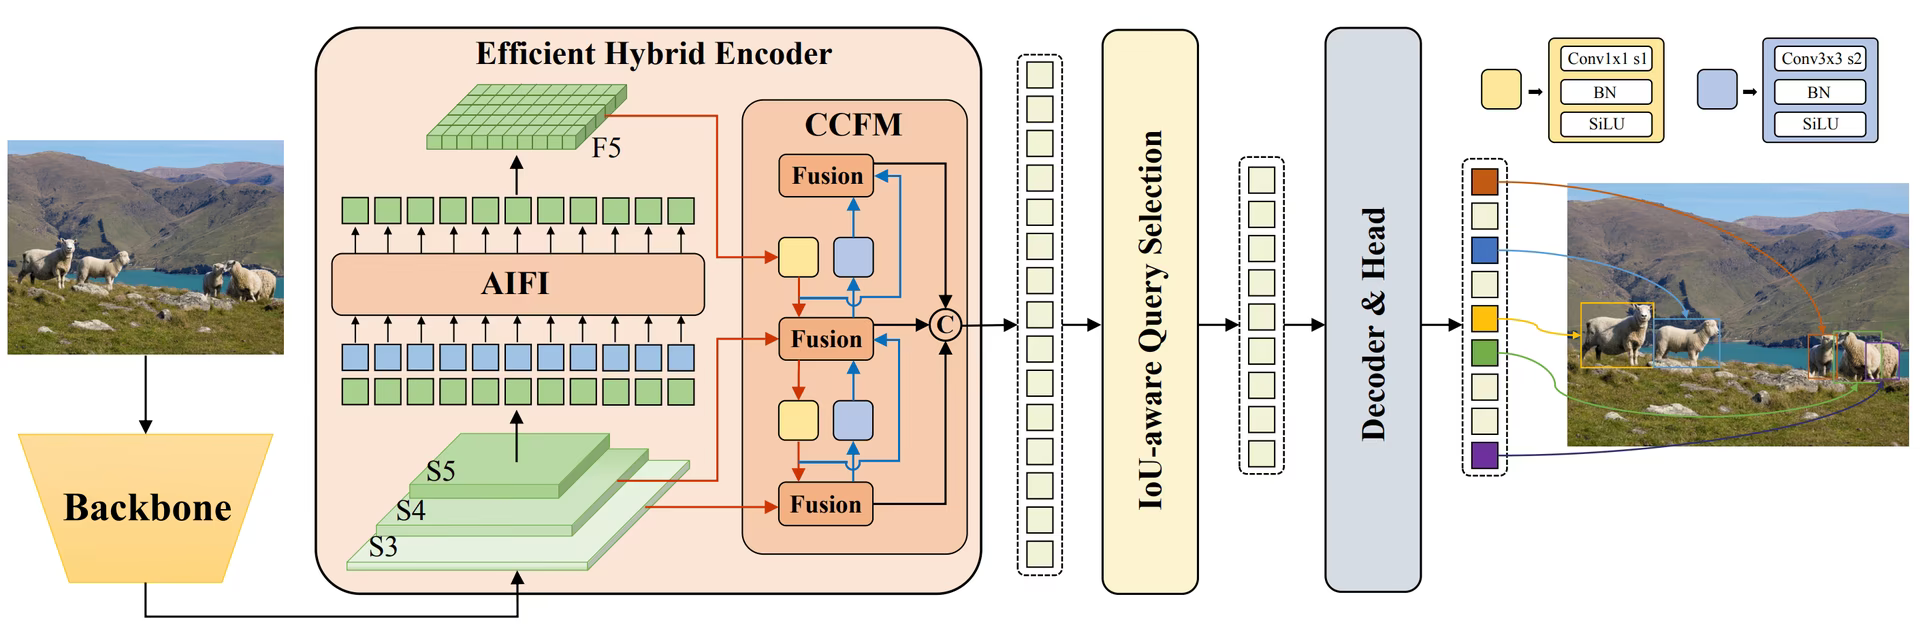

<figcaption>
    Figure 2. RT-DETR architecture as shown in the research paper [5].
  </figcaption>

These feature maps are flattened into feature vectors, which are subsequently encoded with position data. From there, each "location" can look at and compare itself with each other location via self-attention. Patterns and relationships emerge from this self-attention that is subsequently decoded.

Actual object detection is performed by a transformer decoder. Some number of learnable vectors (queries) are initialized, and each begins to interact with the encoded features. Queries learn from each other just as feature vectors did through self-attention, and they grow more and more "attached" to features through training epochs until the final output layer is generated and objects and queries are matched.

# \#3. Model Optimization

This section describes how to optimize/fine-tune these two models. I will discuss the optimization algorithms, learning rates, batch sizes, epoch counts, and training vs validation graphs with helpful explanations to assist in the optimization process. I will explore the values I picked in training my own model and why. Understanding these parameters and how to modify them will help you tune your own model more precisely to your needs.

I will demonstrate the full optimization loop in section 5 of this tutorial. The purpose of this section is to explore the "knobs" to be tuned and discuss default values I have selected to train my dataset.

## 3.1 - Understanding Optimization/Hyperparameters
The following terms will be helpful in understanding the model-specific content below.

### 3.1.1 - Optimization algorithm and parameters:

Both models utilize the AdamW optimizer. The relevant parameters are learning rate, weight decay, and betas.
- Learning rate - controls how big a step the model takes when updating weights after each batch. High learning rate means aggressive and fast corrections, but could also lead to instability and overcorrection. You may sometimes wish to implement a lower introductory LR to prevent early instability; similarly, you can introduce decay to tune more finely over time.
- Weight decay - prevents overfitting by keeping weights small unless absolutely necessary. Essentially, weight decay discourages the model from relying too heavily on any single feature. __This is especially pertinent in SAR applications, ensuring the model learns more general ship features rather than memorizing specific conditions ships appear in in the data.__
- Betas - Adam's algorithms use two moving averages, known as $β_1$ and $β_2$, to control/oppose loss. In any given epoch, the model knows its current state and its past movements. We use these betas to "oppose the flow of loss" as it were - the gradients.
   - $β_1$, the momentum, controls how much past gradients influence the current update. This controls direction smoothing. Essentially, each epoch has a "direction" that drives up loss the most. We want to be aware of that to minimize the loss, but as these directions can change with each step, we use a weighted average to not overcorrect or zigzag.
   - $β_2$, the variance, controls the stability of step size - how much the model adapts based on variations in the gradient. Between epochs, the "magnitude" of the gradient can also change drastically - sometimes there are very dramatic swings. If $β_1$ is a mean, $β_2$ should naturally be a variance. If past gradients have been very large, we want to take more careful, controlled steps until we stabilize.

### 3.1.2 - Batch size:
We compute our gradients on batches, not on the entire set. This is especially true of a project like this with a relatively small dataset. Many factors play into selection of batch size, including but not limited to:
- Generalization - small batches tend to improve generalization because they regularize over time. Essentially, a smaller batch is less likely to have outliers meaning that over repeated epochs the calculations will smooth out more consistently.
- Memory usage - this increases with batch size, as one might expect.
- Gradient stability - We don't just want to observe the loss, we want to learn and minimize it over time. Batch size affects gradient noise which has a cascading effect into future epochs. We want to be somewhat stable so that we're moving steadily in a helpful direction, but we also want to be able to escape when outliers are encountered. Note that the Betas also affect this.

### 3.1.3 - Number of epochs:
How many times does the model repeat its learning processes? This varies between models, as each has their own convergence rates. Early stopping is a mechanism that stops the training process if no improvement is detected after a certain number of epochs have passed. Operating with little improvement can actually be detrimental, especially in SAR ship detection contexts, as it allows the model time to micro-adjust to __specific conditions in the data,__ such as specific background noise patterns, which will harm its usefulness on future, unseen data.

### 3.1.4 - Train vs val graphs:
The general goal is for training losses to decrease steadily, with validation decreasing to a plateau. The more similar these curves are, the better (generally). Certain trends in the curves can indicate important discrepancies:
- Validation loss being higher than training loss can suggest overfitting. Consider early stopping or stronger augmentation to minimize noise effects
- Both losses remaining high can indicate underfitting (too little learning at each step). Consider increasing either learning rate or number of epochs
- Fluctuations in validation can occur as a result of the noisy radar signatures of SAR images. Consider using larger batch sizes if possible, or smoothing the LR scheduling.

## 3.2 - YOLO Optimization
Modern YOLO models use an AdamW optimizer. The relevant parameters for optimization are the LR, weight decay, and betas, as discussed above. When training my YOLO model, I used a starting learning rate of 1e-3, implementing cosine decay using built-in Ultralytics methods. I also used a 5-epoch warmup LR. I used a weight decay of 5e-4, a good baseline for SAR applications, and left the betas at their default values ($β_1$ = 0.937, $β_2$ = 0.999). __I *highly* recommend you leave the betas the same unless you need very very fine tuning and you know what you are doing.__

I used a 16 image batch size. For a custom dataset with high-resolution SAR images, it may behoove you to decrease this considerably for the sake of performance. Conversely, if you have access to premium features of Google Colab, you may wish to utilize a stronger GPU runtime and *increase* the batch size.

I trained in 120 epochs with early stopping patience of 20.

## 3.3 - RT-DETR Optimization
RT-DETR is a much more sensitive model than YOLO26; I adjusted my starting parameters to account for this. I used a starting LR of 1e-4, same for the weight decay, with default betas (0.937, 0.999).

I used an 8 image batch size to account for the heavier processing-per-epoch of RT-DETR. I trained in 150 epochs with early stopping patience of 20.

# \#4. Full Training

## 4.1 Top-to-bottom YOLO Training
Training YOLO models is relatively straightforward using the Python Ultralytics library. The following code implements a full training run with the hyperparameters specified in section 3.2.

Training is a very intensive process, and demands a lot of device resources. Training my YOLO26 SAR model with this dataset took around 40 minutes.

Subsequent trainings are likely to put considerable drains on your Colab resources, particularly if you are a free user. Please be aware of this, as a runtime disconnecting in the middle of training can lose you a lot of precious time.

In [ ]:
if (torch.cuda.is_available()):
  print(f"Starting to train and validate YOLO on a {torch.cuda.get_device_name(0)}")
  print(f"Official start time: {datetime.datetime.now().strftime("%c")}. Godspeed\n")
  model = YOLO("yolo26n.pt")
  results = model.train(
      data=f"SSDD/images/train.yaml",
      epochs=120,
      batch=16,
      device=0,

      optimizer="AdamW",
      lr0=1e-3,
      lrf=0.01,
      cos_lr=True,
      warmup_epochs=5,
      weight_decay=5e-4,

      patience=20,
      plots=True,
      project="yolo_production",
      name="yolo_production",
      exist_ok=True,

      verbose=False
  )
  print(f"Completed training at {datetime.datetime.now().strftime("%c")}")
else:
  print("GPU not available, could not complete training.")

Once training is complete, you can save the model and data for further use and analysis by archiving all generated files using this code:

In [ ]:
# Save the entire YOLO run
shutil.make_archive(
    "yolo_production_backup",
    "zip",
    "runs/detect/yolo_production/yolo_production"
)
files.download("yolo_production_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

From there you can investigate the results and plots, as well as export the best model for later use. For information on how to do this, see section 2.1.2.

## 4.2 Top-to-bottom DETR Training
Training RT-DETR models is relatively straightforward using the Python Ultralytics library. The following code implements a full training run with the hyperparameters specified in section 3.3.

Training DETR is an extremely intensive process! Training my RT-DETR SAR model with this dataset took around 2 hours and 40 minutes on one attempt, and about 1.5 hours on a subsequent attempt.

Because I had been working heavily in Colab before training this model, I was almost cut off from my runtime at about epoch 60 of training! Please be aware of this, as a runtime disconnecting in the middle of training can lose you a lot of precious time.

Note: I actually decided in the moment to spend the $10 needed to purchase GPU priority in order to ensure the training completed properly. If that is not an option you are willing to exercise, plan accordingly! You will likely want to set aside your Colab usage so that training is the __only__ task you complete on the day you undertake it.

In [ ]:
if (torch.cuda.is_available()):
  print(f"Starting to train and validate RT-DETR on a {torch.cuda.get_device_name(0)}")
  print(f"Official start time: {datetime.datetime.now().strftime("%c")}. Godspeed\n")
  model = RTDETR("rtdetr-l.pt")

  results = model.train(
      data=f"SSDD/images/train.yaml",
      epochs=150,
      batch=8,
      device=0,

      optimizer="AdamW",
      lr0=1e-4,
      lrf=0.01,
      cos_lr=True,
      warmup_epochs=5,
      weight_decay=1e-4,

      patience=20,
      plots=True,
      project="detr_production",
      name="detr_production",
      exist_ok=True,

      verbose=False
  )
  print(f"Finished training at {datetime.datetime.now().strftime("%c")}")
else:
  print("No GPU available, could not train.")

In [ ]:
# Save the entire RT-DETR run
shutil.make_archive(
    "rtdetr_production_backup",
    "zip",
    "runs/detect/detr_production/"
)
files.download("rtdetr_production_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# \#5. Basic Fine-Tuning
Download a pre-trained model, setup the optimization loop, and show
that the loss function is getting reduced. Retrain the pre-trained
model for a few iterations to demonstrate the optimization process.

## 5.1 Fine-Tuning the YOLO Model

To demonstrate fine-tuning, I'll use my pretrained `CT_yolo26_SAR.pt` model, iterating over 10 epochs and demonstrating loss reduction.

Because we already have a model with decent performance, I will reduce the learning rate in hopes of __finer__ tuning. This is especially relevant given that the model quit early in training - we want improvements, even small ones, but we don't want to overfit.

In [ ]:
if (torch.cuda.is_available()):
  print(f"Starting to optimize a pretrained YOLO model on a {torch.cuda.get_device_name(0)}")
  print(f"Official start time: {datetime.datetime.now().strftime("%c")}. Godspeed\n")
  model = YOLO("CT_yolo26_SAR.pt")

  results = model.train(
      data=f"SSDD/images/train.yaml",
      epochs=10,
      batch=16,
      device=0,

      optimizer="AdamW",
      lr0=1e-4,
      lrf=0.01,
      cos_lr=True,
      weight_decay=1e-4,

      patience=20,
      plots=True,
      project="yolo_opt",
      name="yolo_opt",
      exist_ok=True,

      #verbose=False
  )
  print(f"Finished training at {datetime.datetime.now().strftime("%c")}")
else:
  print("No GPU available, could not optimize.")

## 5.2 Fine-Tuning the RT-DETR Model
To demonstrate fine-tuning, I'll use my pretrained `CT_rtdetr_SAR.pt` model, iterating over 10 epochs and demonstrating loss reduction.

Because we already have a model with decent performance, I will reduce the learning rate in hopes of __finer__ tuning. This is especially relevant given that the model quit early in training - we want improvements, even small ones, but we don't want to overfit.

In [ ]:
if (torch.cuda.is_available()):
  print(f"Starting to optimize RT-DETR on a {torch.cuda.get_device_name(0)}")
  print(f"Official start time: {datetime.datetime.now().strftime("%c")}. Godspeed\n")
  model = RTDETR("CT_rtdetr_SAR.pt")

  results = model.train(
      data=f"SSDD/images/train.yaml",
      epochs=10,
      batch=8,
      device=0,

      optimizer="AdamW",
      lr0=5e-5,
      lrf=0.01,
      cos_lr=True,
      weight_decay=1e-4,

      patience=20,
      plots=True,
      project="detr_opt",
      name="detr_opt",
      exist_ok=True,

      #verbose=False
  )
  print(f"Finished training at {datetime.datetime.now().strftime("%c")}")
else:
  print("No GPU available, could not optimize.")

# \#6. Basic Testing Tutorial
For this section I will once again use my pre-trained models to run an actual test on an image from the dataset. I have selected the following image for testing, as it represents a complicated example worth investigating:

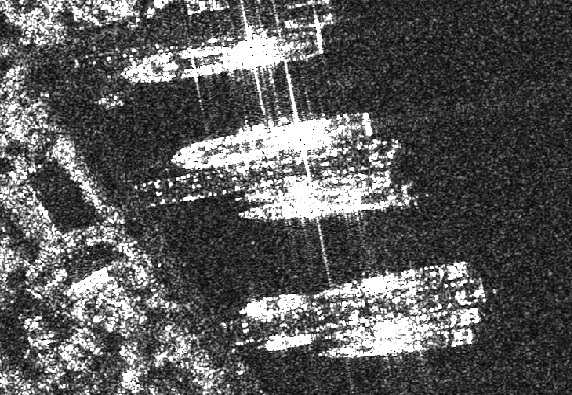

<figcaption>Figure 3 - Image 000219.jpg from the SAR ship detection dataset [1]</figcaption>

The shapes of several ships are available in the water here, but could easily be mistaken with the docks they sit beside. Ideally our models should now be robust enough to handle this with high confidence.

## 6.1 Testing the YOLO Model


image 1/1 /content/SSDD/images/test/000219.jpg: 448x640 7 ships, 317.3ms
Speed: 35.1ms preprocess, 317.3ms inference, 67.6ms postprocess per image at shape (1, 3, 448, 640)


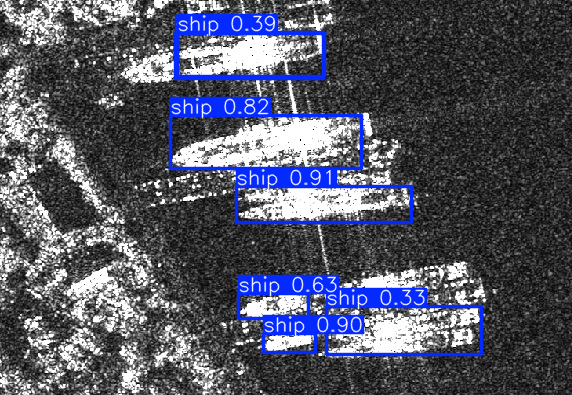

'yolo_test.jpg'

In [ ]:
test_img = 'SSDD/images/test/000219.jpg'

model = YOLO('CT_yolo26_SAR.pt')
results = model(test_img)

results[0].show()
results[0].save(filename="yolo_test.jpg")

Some of the limitations of YOLO are at play here. It clearly doesn't know what to do with the cluster of ships at the bottom of the image, and even the relatively clear one at the top is partially excluded from the bounding box, with low confidence. We will discuss the implications of this in section 7.

## 6.2 Testing the DETR Model


image 1/1 /content/SSDD/images/test/000219.jpg: 640x640 9 ships, 69.4ms
Speed: 2.2ms preprocess, 69.4ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


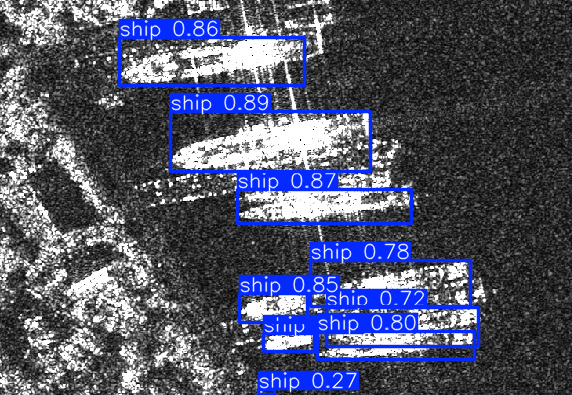

'detr_test.jpg'

In [ ]:
test_img = 'SSDD/images/test/000219.jpg'

model = YOLO('CT_rtdetr_SAR.pt')
results = model(test_img)

results[0].show()
results[0].save(filename="detr_test.jpg")

In spite of the high noise and crowdedness of this image, the DETR model does a relatively good job picking out ships, and certainly does better than the YOLO model. That said, it does have its own issues, such as the low confidence label at the very bottom center. We will compare them further in the section below.

# \#7. Comparison and Analysis Tutorial
The end goal of this tutorial is to compare the YOLO model to the DETR and discover, with relatively low effort up front, which is more effective for SAR ship detection applications. To that end, I wish to compare each model on the following criteria:

* Loss convergence. We want to minimize training and validation wherever possible. Being able to converge to low loss values is an indicator of a strong model.
* Confusion matrices. Because both models were trained and validated on the same data, we can directly compare the true and false positives and negatives between them.
* F1 score. Precision and recall are crucial metrics for this application. We want everything we call a ship to truly be one, and we want to be able to find all ships. Thus, the score representing a strong harmony of both of these desires is a very valuable metric of success for this application. We will investigate both metrics separately, then the F1 score.

--- Data Loading Complete ---
YOLO results shape: (120, 15)
DETR results shape: (72, 15)

--- mAP50-95(B) Comparison ---
YOLO Production Model Max mAP50-95(B): 0.7308
DETR Production Model Max mAP50-95(B): 0.7432



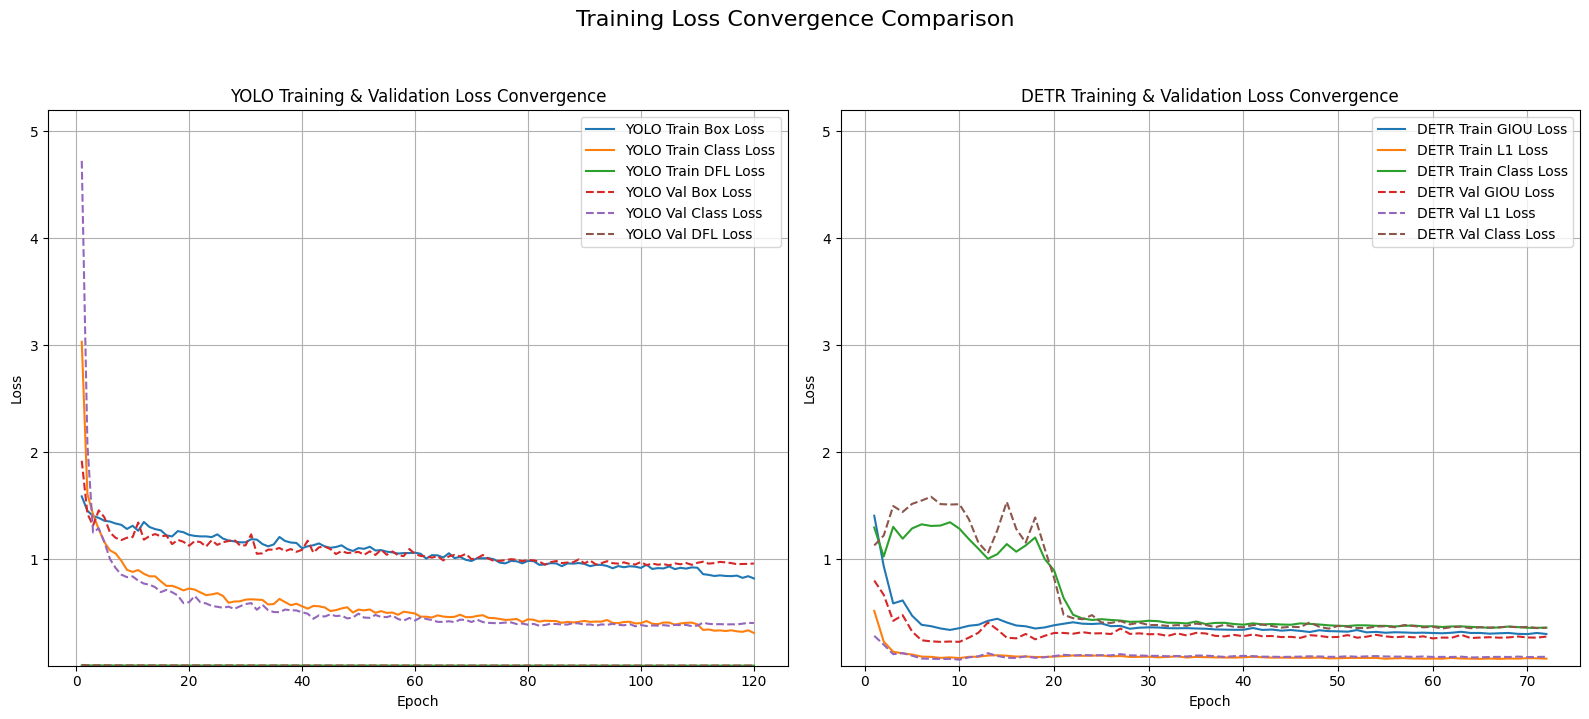

--- Loss Convergence Plots Displayed ---



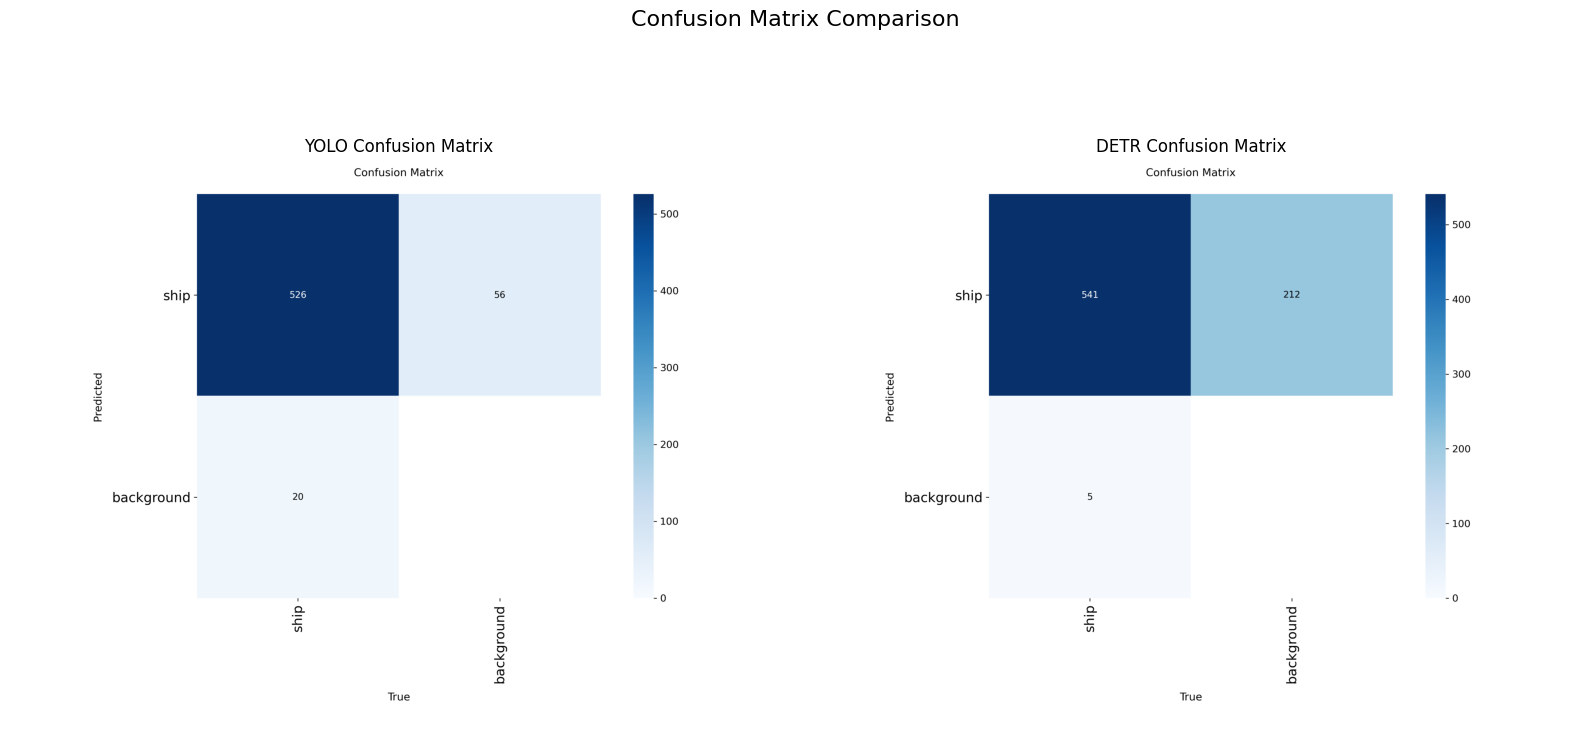

--- Confusion Matrices Displayed ---


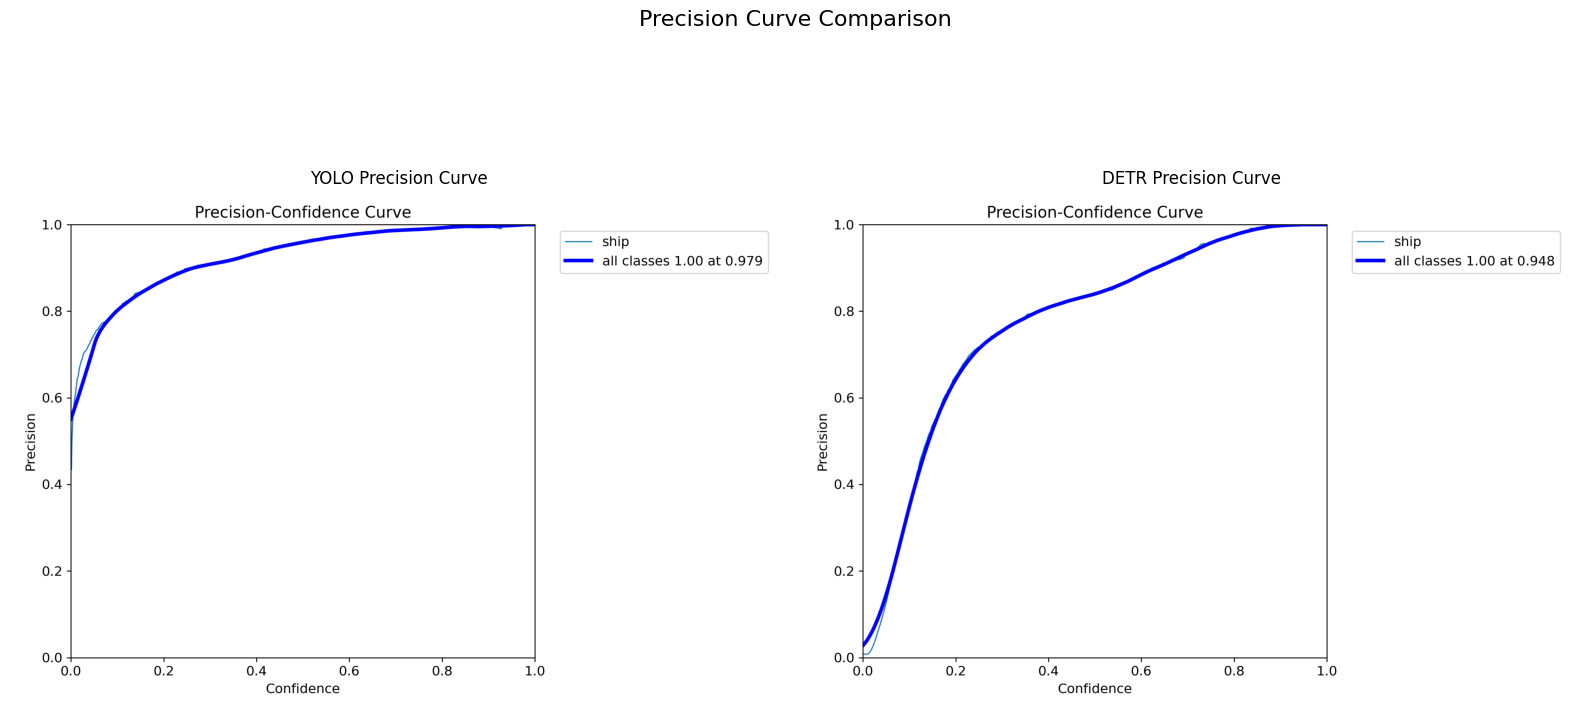

-- Precision Curves Displayed ---


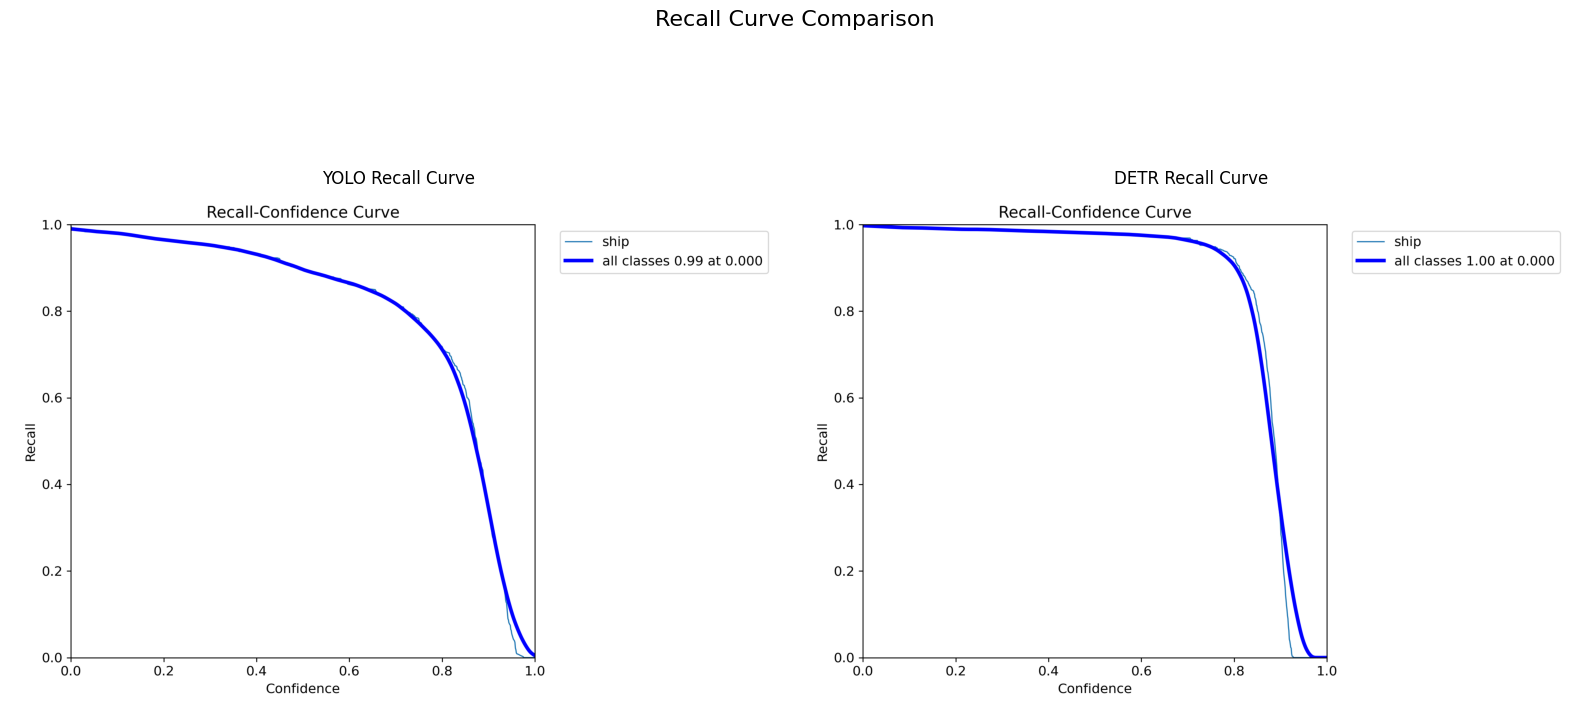

--- Recall Curves Displayed ---


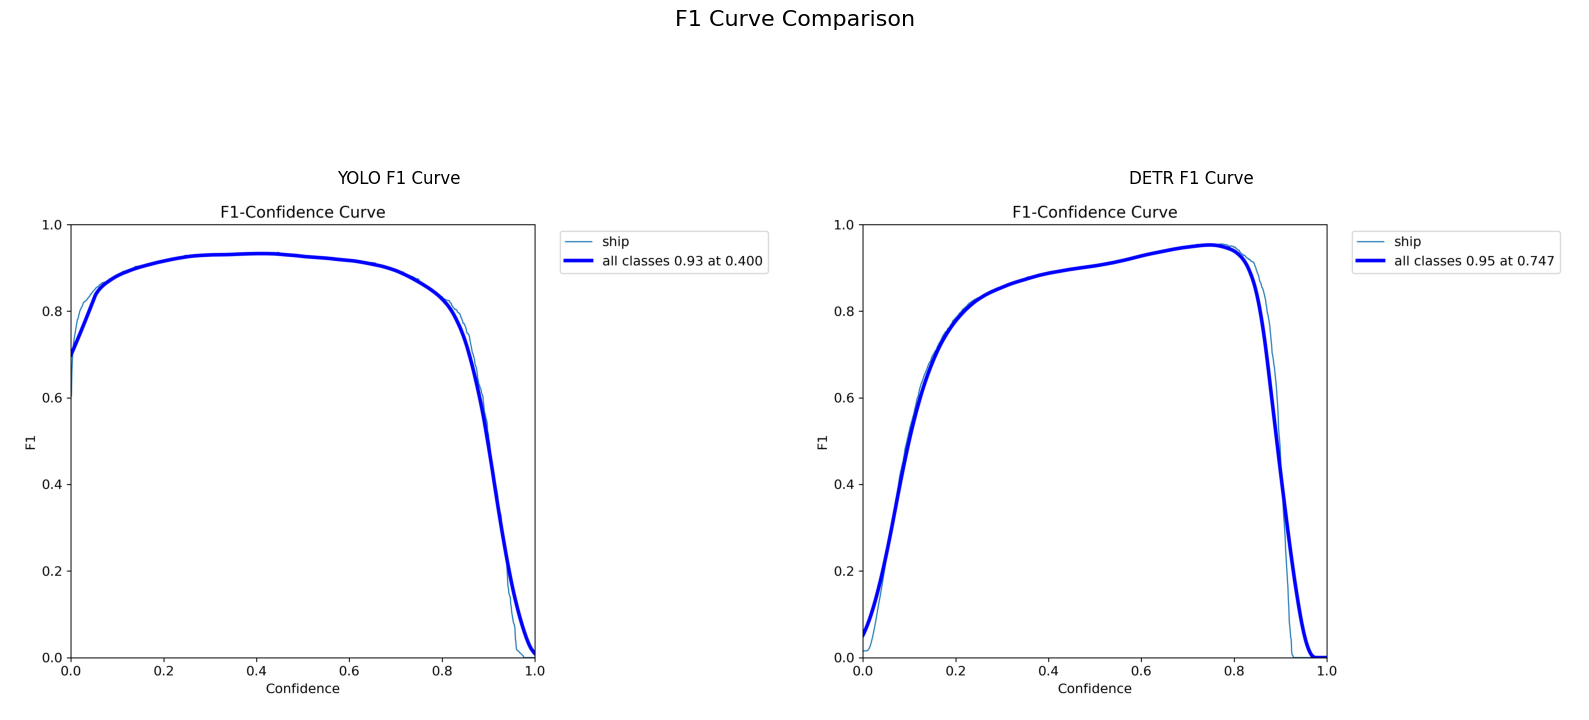

--- F1 Curves Displayed ---


In [3]:
# --- 1. Load results.csv files ---
yolo_results_path = "yolo_prod_results/results.csv"
detr_results_path = "detr_prod_results/results.csv"

# Load dataframes
yolo_df = pd.read_csv(yolo_results_path)
detr_df = pd.read_csv(detr_results_path)

# Clean column names (remove leading/trailing spaces)
yolo_df.columns = [col.strip() for col in yolo_df.columns]
detr_df.columns = [col.strip() for col in detr_df.columns]

print("--- Data Loading Complete ---")
print(f"YOLO results shape: {yolo_df.shape}")
print(f"DETR results shape: {detr_df.shape}\n")

# --- 2. Compare mAP ---
# Compare mAP50-95(B)
yolo_mAP = yolo_df['metrics/mAP50-95(B)'].max()
detr_mAP = detr_df['metrics/mAP50-95(B)'].max()

print(f"--- mAP50-95(B) Comparison ---")
print(f"YOLO Production Model Max mAP50-95(B): {yolo_mAP:.4f}")
print(f"DETR Production Model Max mAP50-95(B): {detr_mAP:.4f}\n")

# --- 3. Plot Training Loss Convergence ---
plt.figure(figsize=(16, 7))

# Collect all loss columns for both dataframes to determine a global y-limit
yolo_loss_cols = ['train/box_loss', 'train/cls_loss', 'val/box_loss', 'val/cls_loss']
detr_loss_cols = ['train/giou_loss', 'train/l1_loss', 'train/cls_loss', 'val/giou_loss', 'val/l1_loss', 'val/cls_loss']

# Add DFL loss if present
if 'train/dfl_loss' in yolo_df.columns:
    yolo_loss_cols.append('train/dfl_loss')
if 'val/dfl_loss' in yolo_df.columns:
    yolo_loss_cols.append('val/dfl_loss')

all_losses = []
for col in yolo_loss_cols:
    if col in yolo_df.columns:
        all_losses.extend(yolo_df[col].dropna().tolist())
for col in detr_loss_cols:
    if col in detr_df.columns:
        all_losses.extend(detr_df[col].dropna().tolist())

global_min_loss = min(all_losses) * 0.9 # Add a small buffer
global_max_loss = max(all_losses) * 1.1 # Add a small buffer

# YOLO Loss Plot
ax1 = plt.subplot(1, 2, 1)
ax1.plot(yolo_df['epoch'], yolo_df['train/box_loss'], label='YOLO Train Box Loss')
ax1.plot(yolo_df['epoch'], yolo_df['train/cls_loss'], label='YOLO Train Class Loss')
if 'train/dfl_loss' in yolo_df.columns:
    ax1.plot(yolo_df['epoch'], yolo_df['train/dfl_loss'], label='YOLO Train DFL Loss')
ax1.plot(yolo_df['epoch'], yolo_df['val/box_loss'], label='YOLO Val Box Loss', linestyle='--')
ax1.plot(yolo_df['epoch'], yolo_df['val/cls_loss'], label='YOLO Val Class Loss', linestyle='--')
if 'val/dfl_loss' in yolo_df.columns:
    ax1.plot(yolo_df['epoch'], yolo_df['val/dfl_loss'], label='YOLO Val DFL Loss', linestyle='--')
ax1.set_title('YOLO Training & Validation Loss Convergence')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)
ax1.set_ylim(global_min_loss, global_max_loss)

# DETR Loss Plot
ax2 = plt.subplot(1, 2, 2)
ax2.plot(detr_df['epoch'], detr_df['train/giou_loss'], label='DETR Train GIOU Loss')
ax2.plot(detr_df['epoch'], detr_df['train/l1_loss'], label='DETR Train L1 Loss')
ax2.plot(detr_df['epoch'], detr_df['train/cls_loss'], label='DETR Train Class Loss')
ax2.plot(detr_df['epoch'], detr_df['val/giou_loss'], label='DETR Val GIOU Loss', linestyle='--')
ax2.plot(detr_df['epoch'], detr_df['val/l1_loss'], label='DETR Val L1 Loss', linestyle='--')
ax2.plot(detr_df['epoch'], detr_df['val/cls_loss'], label='DETR Val Class Loss', linestyle='--')
ax2.set_title('DETR Training & Validation Loss Convergence')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)
ax2.set_ylim(global_min_loss, global_max_loss)

plt.suptitle('Training Loss Convergence Comparison', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("--- Loss Convergence Plots Displayed ---\n")

# --- 4. Display Confusion Matrices ---
yolo_cm_path = "yolo_prod_results/confusion_matrix.png"
detr_cm_path = "detr_prod_results/confusion_matrix.png"

plt.figure(figsize=(16, 8))

# YOLO Confusion Matrix
plt.subplot(1, 2, 1)
yolo_cm_img = Image.open(yolo_cm_path)
plt.imshow(yolo_cm_img)
plt.title('YOLO Confusion Matrix')
plt.axis('off')

# DETR Confusion Matrix
plt.subplot(1, 2, 2)
detr_cm_img = Image.open(detr_cm_path)
plt.imshow(detr_cm_img)
plt.title('DETR Confusion Matrix')
plt.axis('off')

plt.suptitle('Confusion Matrix Comparison', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("--- Confusion Matrices Displayed ---")

# --- 5. Display Precision Curves ---
yolo_p_curve_path = "yolo_prod_results/BoxP_curve.png"
detr_p_curve_path = "detr_prod_results/BoxP_curve.png"

plt.figure(figsize=(16, 8))

# YOLO Precision Curve
plt.subplot(1, 2, 1)
yolo_p_curve_img = Image.open(yolo_p_curve_path)
plt.imshow(yolo_p_curve_img)
plt.title('YOLO Precision Curve')
plt.axis('off')

# DETR Precision Curve
plt.subplot(1, 2, 2)
detr_p_curve_img = Image.open(detr_p_curve_path)
plt.imshow(detr_p_curve_img)
plt.title('DETR Precision Curve')
plt.axis('off')

plt.suptitle('Precision Curve Comparison', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("-- Precision Curves Displayed ---")

# --- 6. Display Recall Curves ---
yolo_r_curve_path = "yolo_prod_results/BoxR_curve.png"
detr_r_curve_path = "detr_prod_results/BoxR_curve.png"

plt.figure(figsize=(16, 8))

# YOLO Recall Curve
plt.subplot(1, 2, 1)
yolo_r_curve_img = Image.open(yolo_r_curve_path)
plt.imshow(yolo_r_curve_img)
plt.title('YOLO Recall Curve')
plt.axis('off')

# DETR Recall Curve
plt.subplot(1, 2, 2)
detr_r_curve_img = Image.open(detr_r_curve_path)
plt.imshow(detr_r_curve_img)
plt.title('DETR Recall Curve')
plt.axis('off')

plt.suptitle('Recall Curve Comparison', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("--- Recall Curves Displayed ---")

# --- 7. Display F1 Curves ---
yolo_f1_curve_path = "yolo_prod_results/BoxF1_curve.png"
detr_f1_curve_path = "detr_prod_results/BoxF1_curve.png"

plt.figure(figsize=(16, 8))

# YOLO F1 Curve
plt.subplot(1, 2, 1)
yolo_f1_curve_img = Image.open(yolo_f1_curve_path)
plt.imshow(yolo_f1_curve_img)
plt.title('YOLO F1 Curve')
plt.axis('off')

# DETR F1 Curve
plt.subplot(1, 2, 2)
detr_f1_curve_img = Image.open(detr_f1_curve_path)
plt.imshow(detr_f1_curve_img)
plt.title('DETR F1 Curve')
plt.axis('off')

plt.suptitle('F1 Curve Comparison', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("--- F1 Curves Displayed ---")

What can we learn from these plots?

## 7.1 - Train/Val Losses
Despite a rough start relative to the rest of its curve, all of the losses measured in DETR training converge to much lower values than those in YOLO. DETR models are much more sensitive as it is, and they become very stable in fewer epochs.

## 7.2 - Confusion Matrices
We will investigate this later when we look at precision and recall, but the DETR model does seem to classify background shapes as ships more often than the YOLO model does. This *can* be a bad sign, but is not in and of itself a complete dealbreaker.

## 7.3 - Precision, Recall, F1 Score
Generally speaking, the YOLO model appears to have better precision across more of the confidence axis than DETR. This is reversed for recall. What this means is that the YOLO model is better at picking ships correctly, but not as good at identifying every ship. Conversely, the DETR model is more likely to identify all ships in an image, but also more likely to mislabel a non-ship by mistake.

What matters most in these contexts is the harmony of these two metrics. DETR has a higher peak F1 score, while YOLO has better average results (a smoother 'plateau').

## 7.4 - Concluding Thoughts
Generally, these results are a lot more similar than I thought they would be. I took general purpose models for both of these structures and trained them on a relatively small set of SAR data, so it makes sense that, with the relatively low rigor I applied to training, they would both have similar output. Having said that, I personally believe that DETR is the more useful model structure for this particular application. There are a lot of complexities introduced by noise in SAR image processing, and I believe that transformer architecture is better equipped to handle that.

For something like this - a quick, easily set-up student project - YOLO is a very reasonable model to use. It converged to reasonable levels, and has pretty good precision with just okay recall. But for a context as important as detecting potentially hostile vessels at sea, 'just okay' is rarely good enough. Transformer learning is more likely to get the very fine features right over time.